# GTEx LORO Tensor Reconstructions — Single

Standalone single-tensor renders of the held-out `loro_truth` and its
reconstruction `loro_recon`, on the matched native-GTEx-parcel axis
(`region_matched`). Region ticks are dense (`REGION_TICK_STEP=1`) so every
parcel is labeled. Dense `loro_fused` / `fullfit` and all AHBA joint renders
live in `eval_gxp_samples_predictions_joint.ipynb`.

In [29]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src.eval_utils.eval_style import set_academic_style
from src.eval_utils.eda_core import prepare_pre_post_harmonization_cached
from src.eval_utils.results_eda import EDAConfig

from src.eval_utils.eval_flattened import (
    build_flattened_tensor_matrix,
    build_paired_flattened_tensor_matrices,
    gene_correlation_table,
    plot_flattened_tensor_matrices,
    plot_flattened_tensor_matrix,
    sample_correlation_table,
)
from src.eval_utils.eval_samples import (
    MatchingContext,
    build_combat_tensor_view,
    build_prediction_tensor_view,
    plot_gtex_tensor_voxels,
)

set_academic_style()

In [30]:
SMALL = True

# Cache pointer must match cfg below: cache_root encodes the matching policy.
#   loro_subject_cache_cv → centroids_and_volumes
#   loro_subject_cache_c  → centroids
CACHE_ROOT = 'out/loro_subject_cache_cv'
MODEL_NAME = 'dlam'    # active model for standalone 3D tensor renders
GENE_SCOPE = 'allgenes'

CSV_PATH = 'data/raw/gxp_samples.csv'   # caches were built against the full CSV
ACTIVE_GENE_LIST = 'richiardi2015'        # post-cube gene-axis filter; None keeps all

MATCHING_POLICY = 'centroids_and_volumes'
MATCHING_POLICY_HEMI_MODE = 'force_left'
GTEX_REP_MODE = 'centroid'
GTEX_HEMI_MODE = 'mirror_left'
COLLAPSE_CEREBELLUM = False
MIN_OBSERVED_PARCELS = 5
COMBAT_USE_COVARIATES = True

# Region axis: matched native-GTEx parcels only (no AHBA-only superset block).
REGION_ORDERING = 'region_matched'

# Subsampling.
N_GTEX_SUBJECTS = 40 if SMALL else 200
N_AHBA_SUBJECTS = 6
N_GENES = 100 if SMALL else None
N_REGIONS = 80 if SMALL else None
RANDOM_SEED = 42

# Pre-filter subject list before loading (avoids stacking the full ~300 npz files).
import random as _random
_random.seed(RANDOM_SEED)
_all_subjects = sorted(p.stem for p in (Path(CACHE_ROOT) / GENE_SCOPE / MODEL_NAME).glob('*.npz'))
if SMALL and N_GTEX_SUBJECTS < len(_all_subjects):
    SUBJECTS_TO_LOAD = sorted(_random.sample(_all_subjects, N_GTEX_SUBJECTS))
else:
    SUBJECTS_TO_LOAD = None
print(f'npz subjects available: {len(_all_subjects)}; loading: '
      f'{len(SUBJECTS_TO_LOAD) if SUBJECTS_TO_LOAD else len(_all_subjects)}')

# Standalone single-tensor stages: held-out truth and its reconstruction.
STAGES = ('loro_truth', 'loro_recon')
STAGE_TITLES = {
    'loro_truth':  'LORO truth (held-out)',
    'loro_recon':  'LORO recon (held-out predictions)',
}

# Render knobs (same as combat notebook for A/B comparability)
MISSING_ALPHA = 1.0
# First pass: no translucency — extrapolated predictions render fully opaque.
# Titrate this < 1.0 later to encode prediction uncertainty.
FUTURE_IMPUTATION_ALPHA = 1.0
MASK_RENDER_MODE = 'two_pass'
FIGSIZE = 'auto'
AXES_BBOX = 'auto'
COLORBAR_BBOX = 'auto'
BOX_ASPECT = 'compressed_data'
BOX_ZOOM = 1
DPI = 300 if SMALL else 400
TITLE_PAD = 0.0
AXIS_ASSIGNMENT = ('gene', 'region', 'subject')
ELEV = 20.0
AZIM = 24.0
SUBJECT_TICK_STEP = 2
GENE_TICK_STEP = 10
REGION_TICK_STEP = 1
TICK_LABEL_PAD = -3.0
SUBJECT_LABEL_MODE = 'full'
GENE_LABEL_MODE = 'full'
SHOW_X_AXIS_LABEL = True
SHOW_Y_AXIS_LABEL = None
SHOW_Z_AXIS_LABEL = None
SHOW_AXIS_LABELS = False
SHOW_SUBJECT_TICKLABELS = True
SHOW_REGION_TICKLABELS = True
SHOW_REGION_LABEL_COLORS = False
SHOW_GENE_TICKLABELS = False
SHOW_AXIS_LINES = True
SHOW_TICK_LINES = True
SHOW_GRID = False
SHOW_LEGEND = True


npz subjects available: 318; loading: 40


## Load PREPOST + MatchingContext

`MatchingContext` supplies the parcel/gene axes that label the prediction cubes. No AHBA reference is needed for the single-tensor renders.

In [ ]:
cfg = EDAConfig(
    csv_path=CSV_PATH,
    cache_root=CACHE_ROOT,
    gene_scope=GENE_SCOPE,
    min_observed_parcels=MIN_OBSERVED_PARCELS,
    combat_use_covariates=COMBAT_USE_COVARIATES,
    gtex_rep_mode=GTEX_REP_MODE,
    gtex_hemi_mode=GTEX_HEMI_MODE,
    matching_policy=MATCHING_POLICY,
    matching_policy_hemi_mode=MATCHING_POLICY_HEMI_MODE,
    collapse_cerebellum=COLLAPSE_CEREBELLUM,
)
prepost = prepare_pre_post_harmonization_cached(cfg)
ctx = MatchingContext.from_cfg(cfg, prepost)
print(f'target parcels: {len(ctx.regions_full)}, genes: {len(ctx.genes_full)}')
print(f'matching policy: {ctx.matching["policy"]!r} hemi={ctx.matching["hemi_mode"]!r}')

[prepost_cache] miss notebooks/cache/prepost/0f8616c23cf88e0f.pkl — computing PREPOST (this is the slow path)...


## Build GTEx single-tensor prediction views

In [ ]:
tier_b_kwargs = dict(
    cfg=cfg,
    matching_context=ctx,
    region_ordering=REGION_ORDERING,
    gene_panel=ACTIVE_GENE_LIST,
    n_regions=N_REGIONS,
    n_genes=N_GENES,
    random_seed=RANDOM_SEED,
)

# GTEx single-tensor views (matched axis), one per held-out stage.
gtex_views = {}
for stage in STAGES:
    gtex_views[stage] = build_prediction_tensor_view(
        CACHE_ROOT, MODEL_NAME,
        dataset='GTEx', stage=stage,
        subjects=SUBJECTS_TO_LOAD,
        n_subjects=N_GTEX_SUBJECTS,
        **tier_b_kwargs,
    )

for stage, v in gtex_views.items():
    n_obs = int(v.observed_mask.sum())
    print(f'{stage:12s}: values={v.values.shape}, axis_kind={v.region_axis_kind}, obs_cells={n_obs}')

loro_truth  : values=(40, 12, 97), axis_kind=ahba_parcel, obs_cells=358
loro_recon  : values=(40, 12, 97), axis_kind=ahba_parcel, obs_cells=358


## Standalone GTEx single-dataset renders

In [ ]:
# Render helpers — one tensor per cell below (no plot loops).
_COMMON = dict(
    missing_rgba=(0.78, 0.78, 0.78, MISSING_ALPHA),
    future_imputation_rgba=(0.78, 0.78, 0.78, FUTURE_IMPUTATION_ALPHA),
    figsize=FIGSIZE, dpi=DPI, axes_bbox=AXES_BBOX, colorbar_bbox=COLORBAR_BBOX,
    box_aspect=BOX_ASPECT, box_zoom=BOX_ZOOM, title_pad=TITLE_PAD,
    axis_assignment=AXIS_ASSIGNMENT, elev=ELEV, azim=AZIM,
    subject_tick_step=SUBJECT_TICK_STEP, gene_tick_step=GENE_TICK_STEP,
    region_tick_step=REGION_TICK_STEP, tick_label_pad=TICK_LABEL_PAD,
    subject_label_mode=SUBJECT_LABEL_MODE, gene_label_mode=GENE_LABEL_MODE,
    show_x_axis_label=SHOW_X_AXIS_LABEL, show_y_axis_label=SHOW_Y_AXIS_LABEL,
    show_z_axis_label=SHOW_Z_AXIS_LABEL, show_axis_labels=SHOW_AXIS_LABELS,
    show_subject_ticklabels=SHOW_SUBJECT_TICKLABELS,
    show_region_ticklabels=SHOW_REGION_TICKLABELS,
    show_region_label_colors=SHOW_REGION_LABEL_COLORS,
    show_gene_ticklabels=SHOW_GENE_TICKLABELS,
    show_axis_lines=SHOW_AXIS_LINES, show_tick_lines=SHOW_TICK_LINES,
    show_grid=SHOW_GRID, mask_render_mode=MASK_RENDER_MODE,
)

def _breakdown(view):
    ns, nr, ng = view.values.shape
    return f'{ns} subjects x {nr} regions x {ng} genes'

def render_standalone(stage):
    fig, ax = plot_gtex_tensor_voxels(gtex_views[stage], show_legend=False, **_COMMON)
    ax.set_title(f'GTEx {STAGE_TITLES[stage]}  ({_breakdown(gtex_views[stage])})', pad=float(TITLE_PAD))
    plt.show()
    return ax

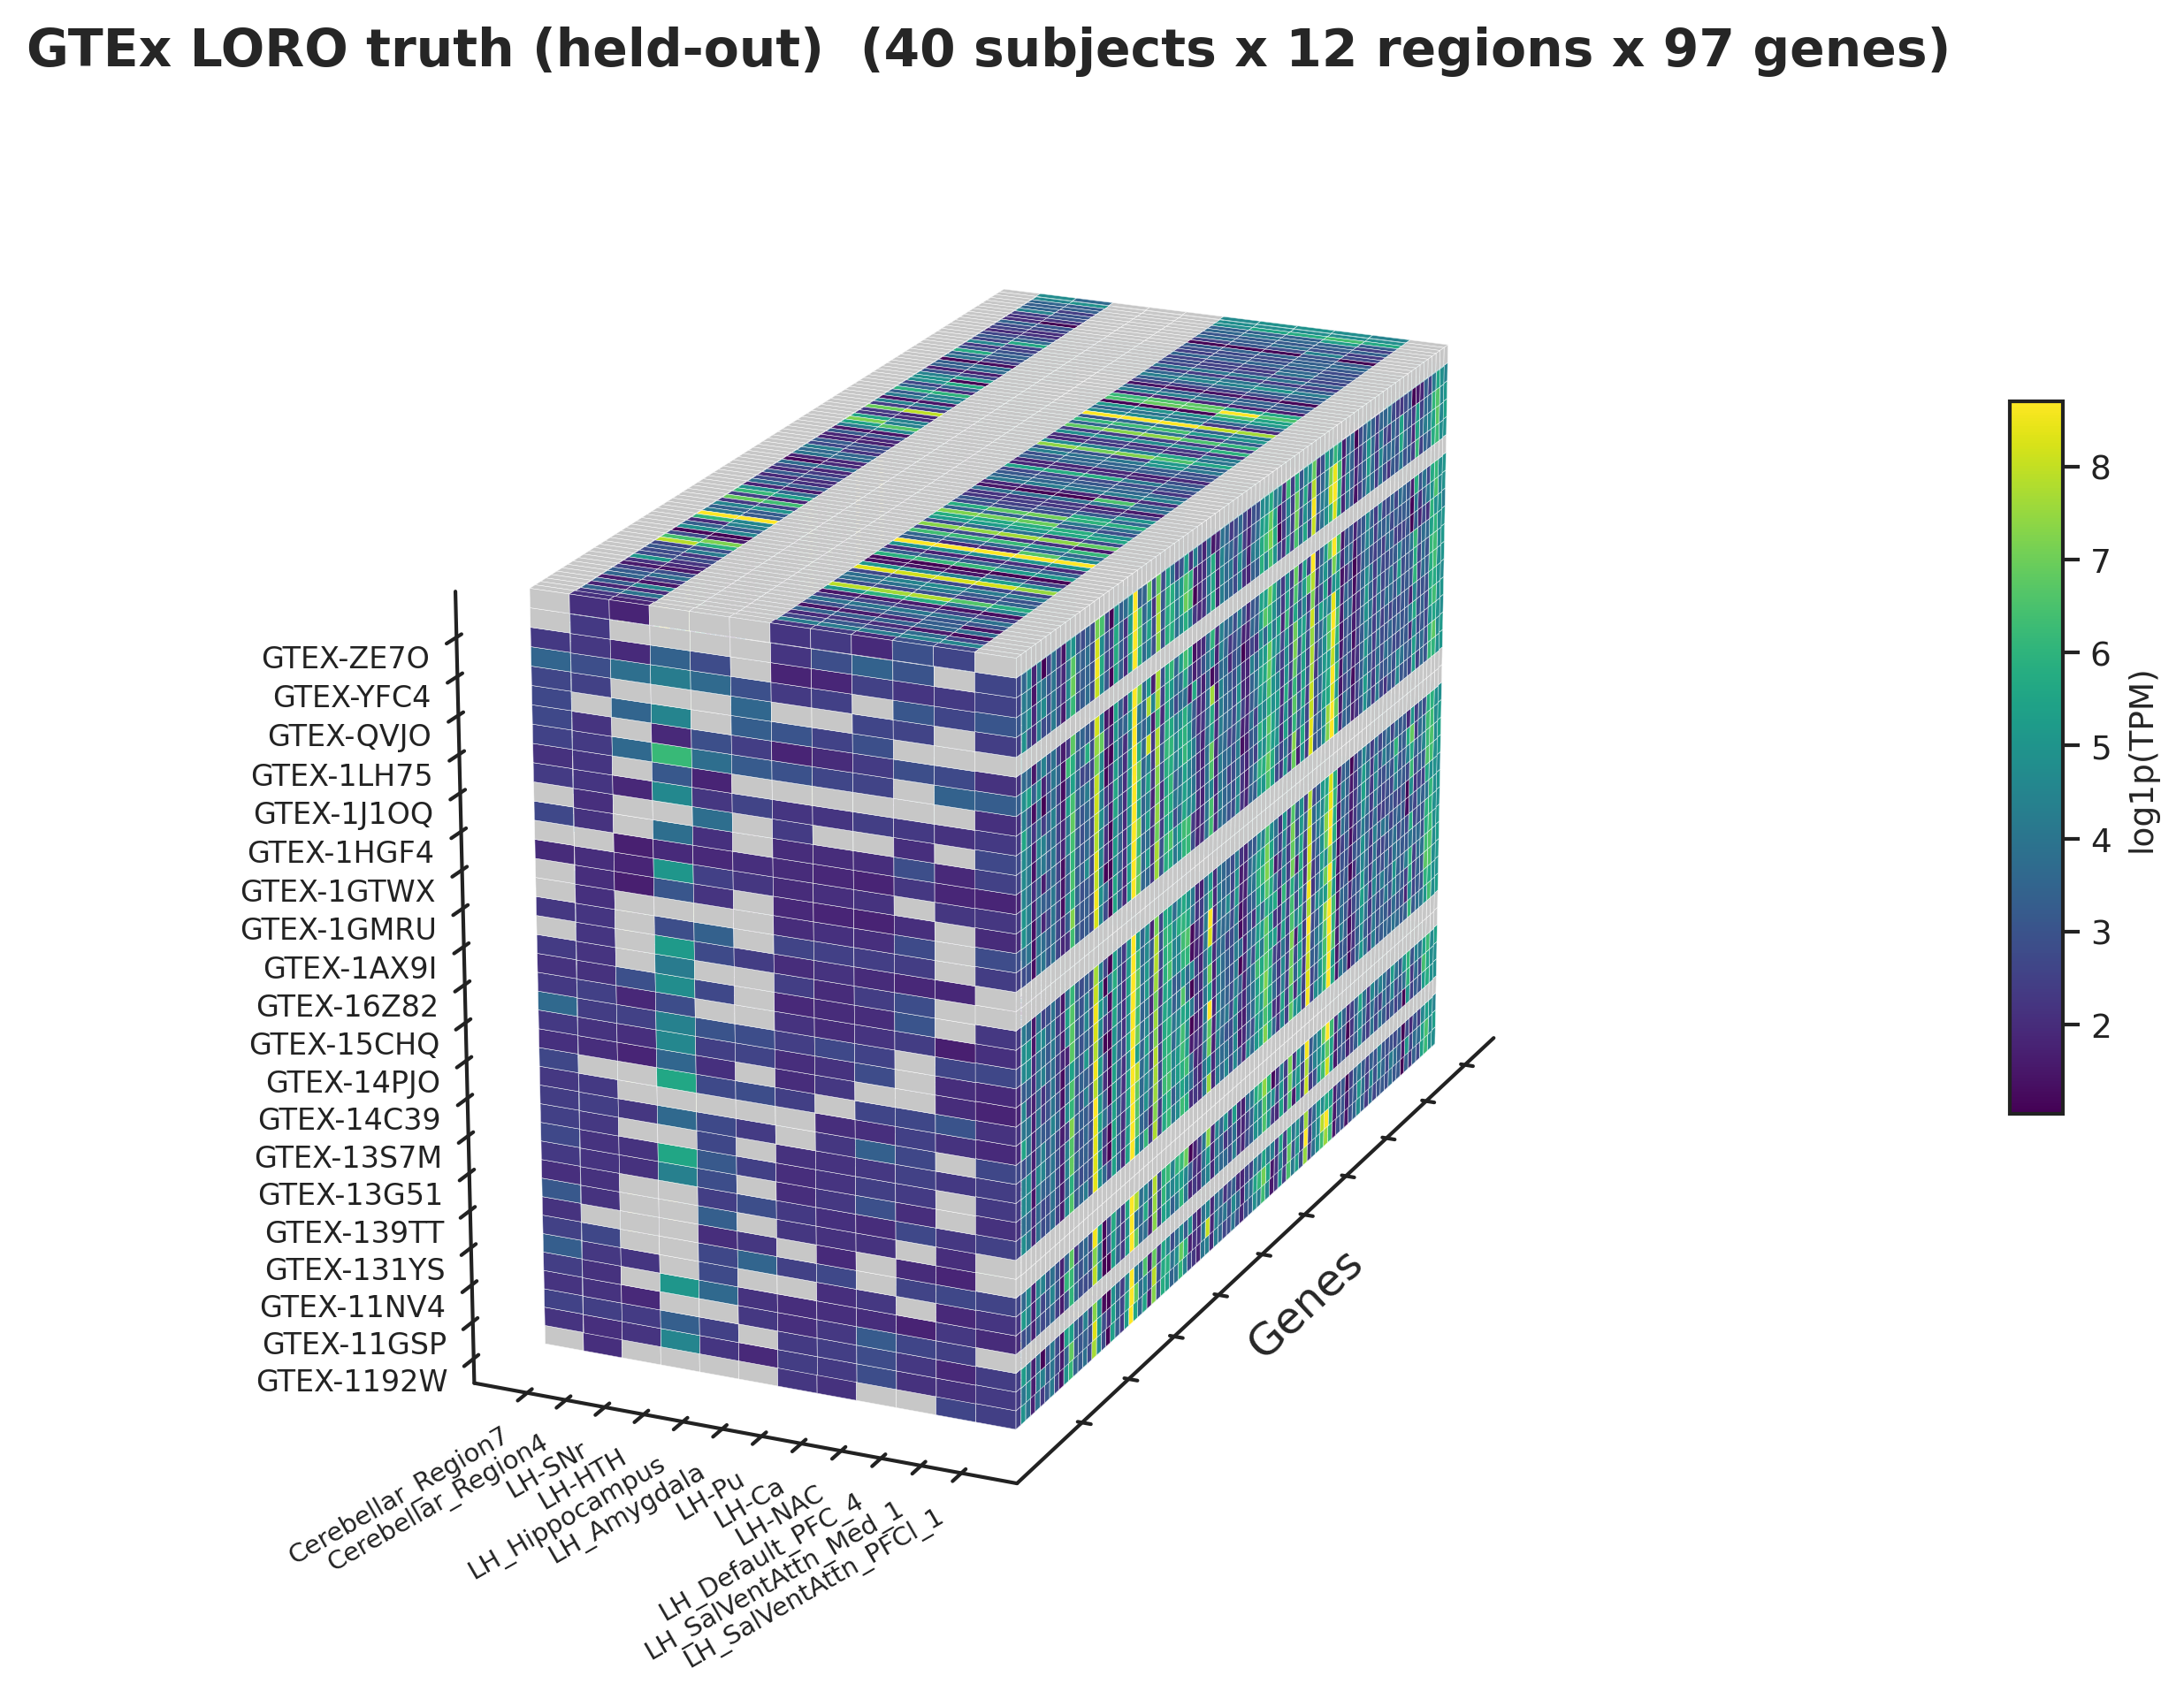

<Axes3D: title={'center': 'GTEx LORO truth (held-out)  (40 subjects x 12 regions x 97 genes)'}, xlabel='Genes'>

In [ ]:
render_standalone('loro_truth')

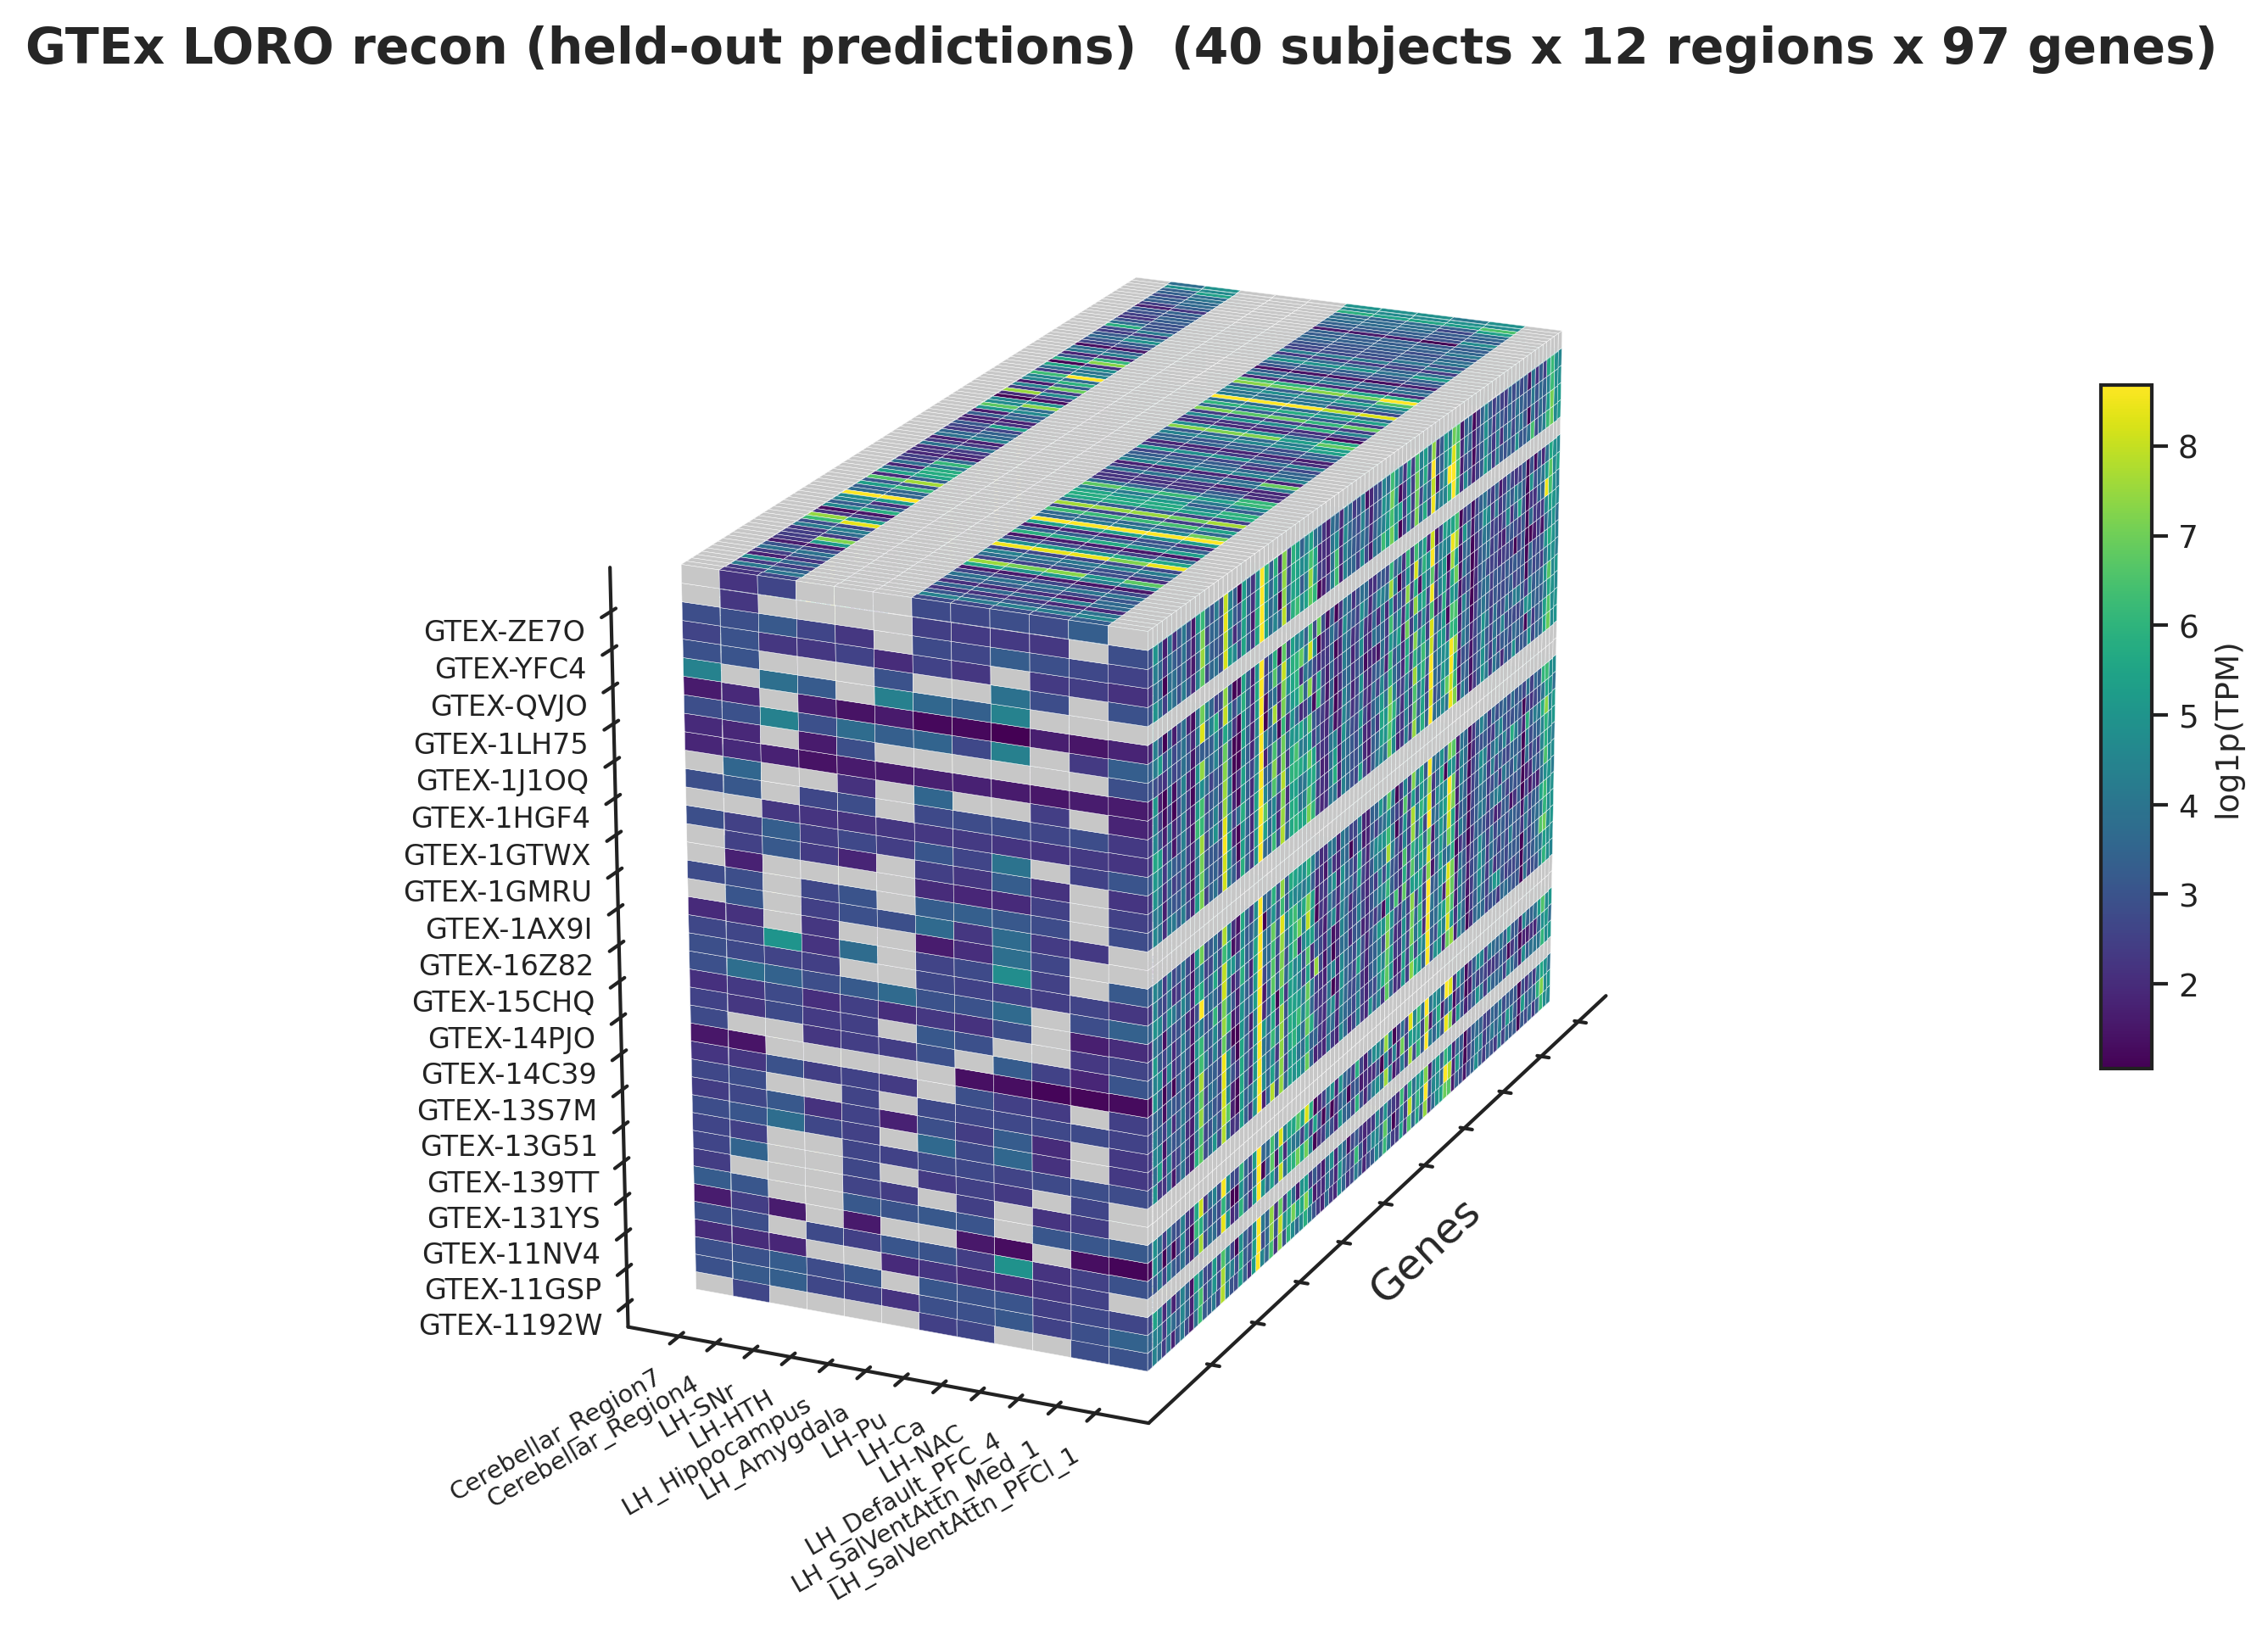

<Axes3D: title={'center': 'GTEx LORO recon (held-out predictions)  (40 subjects x 12 regions x 97 genes)'}, xlabel='Genes'>

In [ ]:
render_standalone('loro_recon')

## Flattened truth/reconstruction matrices

Variantformer-style 2D matrices: rows are observed subject-region samples, columns are genes. The truth, naive, DLAM, and PLAM panels share row order and one color scale.

**Self-contained:** this section builds its own prediction views from a dedicated `MAT_*` config (own subject/gene/region counts, gene panel, region axis). It does not reuse the 3D tensor views above, so the two sections can diverge freely.

In [ ]:
# === Flattened matrix config — independent of the 3D tensor section above ===
# The matrix views are built fresh in the next cell; NOTHING is inherited from
# the tensor render section, so subject / gene / region counts, the gene panel,
# and the region axis can all differ freely from the standalone tensors.

# Reconstruction models compared as panels (truth + one panel per model).
MAT_MODEL_NAMES = ('naive', 'dlam', 'plam')

# Axis selection for the matrices.
MAT_REGION_ORDERING = 'region_matched'
MAT_GENE_PANEL = 'gtex_10deg'   # small DEG panel; 'richiardi2015' / an explicit list / None also work

# Subsampling — independent of the tensor section (can be larger/smaller).
MAT_N_SUBJECTS = 20 if SMALL else 200
MAT_N_GENES = 100 if SMALL else None
MAT_N_REGIONS = 80 if SMALL else None
MAT_RANDOM_SEED = 42

# Own subject prefilter (enumerate from the first model's cache).
import random as _mat_random
_mat_random.seed(MAT_RANDOM_SEED)
_mat_all_subjects = sorted(p.stem for p in (Path(CACHE_ROOT) / GENE_SCOPE / MAT_MODEL_NAMES[0]).glob('*.npz'))
if SMALL and MAT_N_SUBJECTS < len(_mat_all_subjects):
    MAT_SUBJECTS_TO_LOAD = sorted(_mat_random.sample(_mat_all_subjects, MAT_N_SUBJECTS))
else:
    MAT_SUBJECTS_TO_LOAD = None
print(f'matrix npz subjects available: {len(_mat_all_subjects)}; loading: '
      f'{len(MAT_SUBJECTS_TO_LOAD) if MAT_SUBJECTS_TO_LOAD else len(_mat_all_subjects)}')

# Display toggles (decoupled from the tensor tick steps).
FLAT_GROUPBY = 'tissue'
FLAT_SUBJECT_LABEL_MODE = 'full'
FLAT_GENE_LABEL_MODE = 'full'
FLAT_GENE_TICK_STEP = 10
FLAT_SAMPLE_TICK_STEP = 2
FLAT_SHOW_GENE_TICKLABELS = False
FLAT_SHOW_SAMPLE_TICKLABELS = False
FLAT_SHOW_GROUP_LABELS = True
FLAT_SHOW_GROUP_SEPARATORS = False   # set True to draw separating lines between tissues
FLAT_SHOW_YLABEL = False             # y-axis title off by default
FLAT_GROUP_LABEL_X = -0.10
FLAT_GROUP_LABEL_FONTSIZE = 8
FLAT_CMAP = 'viridis'
FLAT_SHARED_COLOR_SCALE = True
FLAT_VMIN = None
FLAT_VMAX = None
FLAT_FIGSIZE = (20, 8)
FLAT_NCOLS = 4
FLAT_DPI = 300                       # high-resolution output for figures

In [ ]:
# Build the matrix views fresh — independent of the 3D tensor section.
mat_tier_b_kwargs = dict(
    cfg=cfg,
    matching_context=ctx,
    region_ordering=MAT_REGION_ORDERING,
    gene_panel=MAT_GENE_PANEL,
    n_regions=MAT_N_REGIONS,
    n_genes=MAT_N_GENES,
    random_seed=MAT_RANDOM_SEED,
)

# Held-out truth (model-invariant; enumerate from the first model's cache) and
# one loro_recon panel per model — all on the same MAT_* subject/axis sampling.
flat_truth_view = build_prediction_tensor_view(
    CACHE_ROOT, MAT_MODEL_NAMES[0],
    dataset='GTEx', stage='loro_truth',
    subjects=MAT_SUBJECTS_TO_LOAD,
    n_subjects=MAT_N_SUBJECTS,
    **mat_tier_b_kwargs,
)

flat_recon_views = {}
for model_name in MAT_MODEL_NAMES:
    flat_recon_views[model_name] = build_prediction_tensor_view(
        CACHE_ROOT, model_name,
        dataset='GTEx', stage='loro_recon',
        subjects=MAT_SUBJECTS_TO_LOAD,
        n_subjects=MAT_N_SUBJECTS,
        **mat_tier_b_kwargs,
    )

flat_matrices = []
flat_recon_matrices = {}
for model_name in MAT_MODEL_NAMES:
    truth_flat, recon_flat = build_paired_flattened_tensor_matrices(
        flat_truth_view,
        flat_recon_views[model_name],
        groupby=FLAT_GROUPBY,
        subject_label_mode=FLAT_SUBJECT_LABEL_MODE,
        truth_title='Truth',
        recon_title=model_name.upper(),
        value_label='Harmonized expression',
    )
    if not flat_matrices:
        flat_truth = truth_flat
        flat_matrices.append(flat_truth)
    flat_recon_matrices[model_name] = recon_flat
    flat_matrices.append(recon_flat)

print(f'flattened matrix: rows={flat_truth.X.shape[0]}, genes={flat_truth.X.shape[1]}')
display(flat_truth.row_metadata.groupby('group_label', sort=False).size().rename('rows').to_frame())

# Raw pre-ComBat GTEx as a standalone matrix (its own subject subsample from
# PREPOST; observed rows don't align with the LORO panels, so it isn't joined
# into the shared panel above).
raw_gtex_view = build_combat_tensor_view(
    prepost, dataset='GTEx', stage='raw_matched',
    n_subjects=MAT_N_SUBJECTS, **mat_tier_b_kwargs,
)
raw_gtex_flat = build_flattened_tensor_matrix(
    raw_gtex_view,
    groupby=FLAT_GROUPBY,
    subject_label_mode=FLAT_SUBJECT_LABEL_MODE,
    title='GTEx raw (pre-ComBat)',
    value_label='Raw expression',
)
print(f'raw GTEx matrix: rows={raw_gtex_flat.X.shape[0]}, genes={raw_gtex_flat.X.shape[1]}')


ValueError: truth_view and recon_view must have identical subject order.

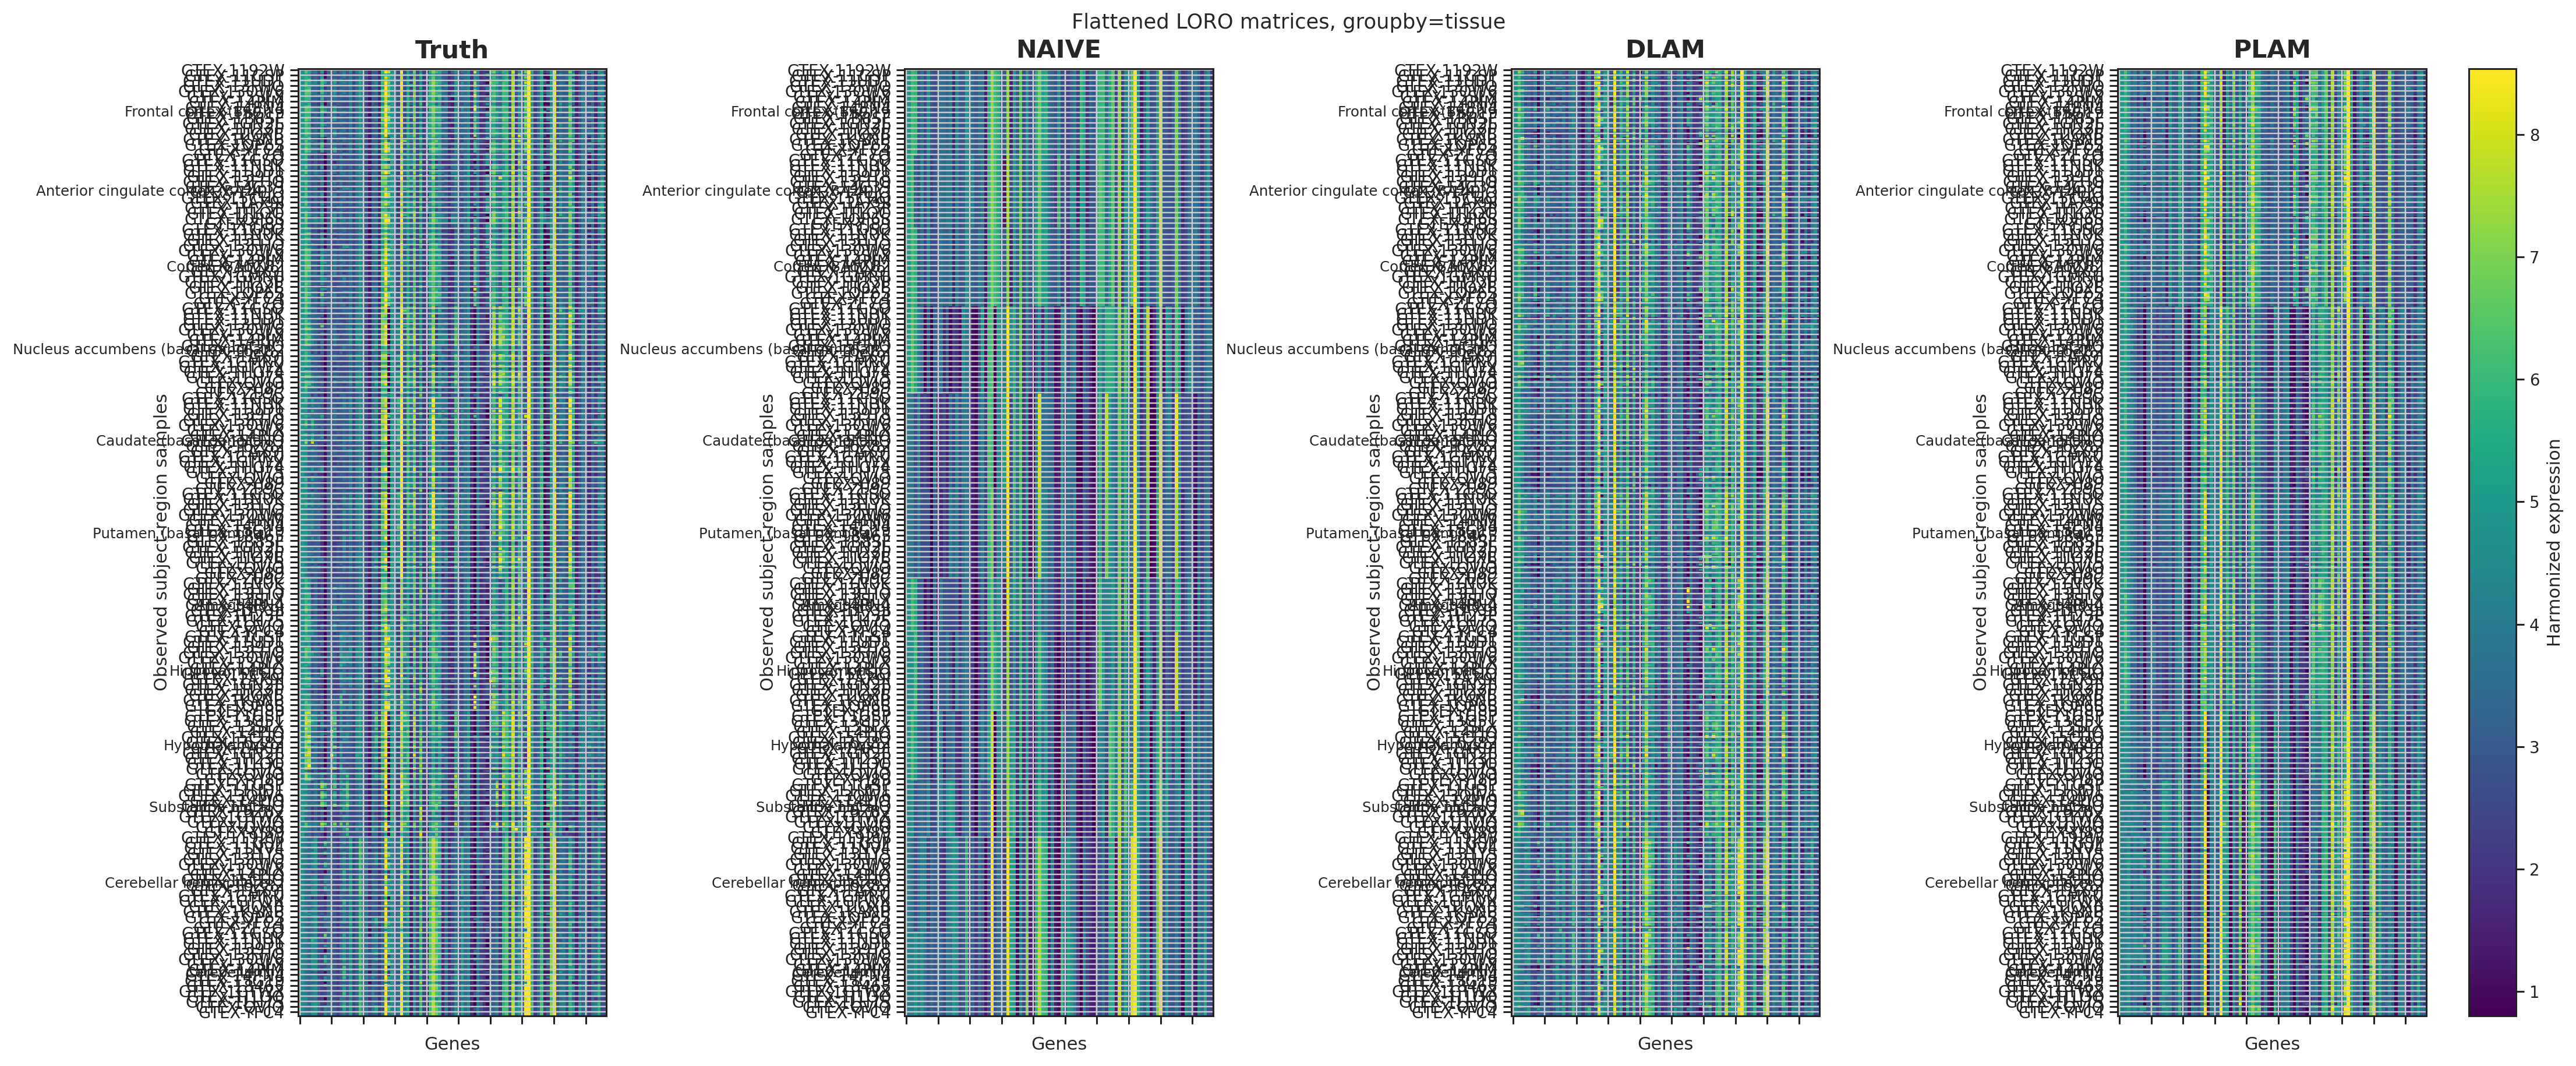

In [ ]:
fig, axes = plot_flattened_tensor_matrices(
    flat_matrices,
    ncols=FLAT_NCOLS,
    figsize=FLAT_FIGSIZE,
    cmap=FLAT_CMAP,
    shared_color_scale=FLAT_SHARED_COLOR_SCALE,
    vmin=FLAT_VMIN,
    vmax=FLAT_VMAX,
    suptitle=f'Flattened LORO matrices, groupby={FLAT_GROUPBY}',
    gene_tick_step=FLAT_GENE_TICK_STEP,
    sample_tick_step=FLAT_SAMPLE_TICK_STEP,
    gene_label_mode=FLAT_GENE_LABEL_MODE,
    show_gene_ticklabels=FLAT_SHOW_GENE_TICKLABELS,
    show_sample_ticklabels=FLAT_SHOW_SAMPLE_TICKLABELS,
    show_group_labels=FLAT_SHOW_GROUP_LABELS,
    show_group_separators=FLAT_SHOW_GROUP_SEPARATORS,
    show_ylabel=FLAT_SHOW_YLABEL,
    group_label_x=FLAT_GROUP_LABEL_X,
    group_label_fontsize=FLAT_GROUP_LABEL_FONTSIZE,
    dpi=FLAT_DPI,
)
plt.show()


## Raw GTEx matrix (pre-ComBat, standalone)

Raw GTEx expression before ComBat harmonization, on its own subject subsample. Rendered standalone because its observed rows / subjects don't align with the LORO truth-recon panels above.

In [ ]:
fig, ax = plot_flattened_tensor_matrix(
    raw_gtex_flat,
    cmap=FLAT_CMAP,
    gene_tick_step=FLAT_GENE_TICK_STEP,
    sample_tick_step=FLAT_SAMPLE_TICK_STEP,
    gene_label_mode=FLAT_GENE_LABEL_MODE,
    show_gene_ticklabels=FLAT_SHOW_GENE_TICKLABELS,
    show_sample_ticklabels=FLAT_SHOW_SAMPLE_TICKLABELS,
    show_group_labels=FLAT_SHOW_GROUP_LABELS,
    show_group_separators=FLAT_SHOW_GROUP_SEPARATORS,
    show_ylabel=FLAT_SHOW_YLABEL,
    group_label_x=FLAT_GROUP_LABEL_X,
    group_label_fontsize=FLAT_GROUP_LABEL_FONTSIZE,
)
fig.set_dpi(FLAT_DPI)
plt.show()

In [ ]:
# Variantformer-style summaries: gene-wise correlations across rows and sample-wise correlations across genes.
gene_corr_tables = []
sample_corr_tables = []
for model_name, recon_flat in flat_recon_matrices.items():
    g = gene_correlation_table(flat_truth, recon_flat)
    g.insert(0, 'model', model_name)
    gene_corr_tables.append(g)
    s = sample_correlation_table(flat_truth, recon_flat)
    s.insert(0, 'model', model_name)
    sample_corr_tables.append(s)

gene_corr = pd.concat(gene_corr_tables, ignore_index=True)
sample_corr = pd.concat(sample_corr_tables, ignore_index=True)

display(gene_corr.groupby('model')['pearson_r'].describe())
display(sample_corr.groupby(['model', 'group_label'])['pearson_r'].describe())


,count,mean,std,min,25%,50%,75%,max
model,,,,,,,,
dlam,97.0,0.377845,0.157879,-0.071362,0.262210,0.391107,0.499696,0.711123
naive,97.0,0.399521,0.242371,-0.115423,0.211687,0.421018,0.560009,0.878031
plam,97.0,0.307802,0.252866,-0.371977,0.116599,0.337796,0.500099,0.762570


count      mean       std       min  \
model group_label                                                              
dlam  Amygdala                            20.0  0.821916  0.065779  0.675872   
      Anterior cingulate cortex (BA24)    27.0  0.859312  0.062735  0.645043   
      Caudate (basal ganglia)             36.0  0.888979  0.043630  0.786690   
      Cerebellar hemisphere               36.0  0.904018  0.074764  0.695299   
      Cerebellum                          32.0  0.914003  0.081420  0.634492   
      Cortex (BA10)                       30.0  0.885467  0.058004  0.737787   
      Frontal cortex (BA9)                33.0  0.841698  0.087295  0.635882   
      Hippocampus                         30.0  0.752165  0.107382  0.520822   
      Hypothalamus                        26.0  0.796021  0.054055  0.667866   
      Nucleus accumbens (basal ganglia)   33.0  0.841662  0.068065  0.625279   
      Putamen (basal ganglia)             34.0  0.886197  0.062030  0.672253   
      Substantia nigra                    21.0  0.777058  0.068200  0.644633   
naive Amygdala                            20.0  0.908216  0.028279  0.818324   
      Anterior cingulate cortex (BA24)    27.0  0.836532  0.076406  0.673880   
      Caudate (basal ganglia)             36.0  0.921748  0.052260  0.713590   
      Cerebellar hemisphere               36.0  0.896771  0.027480  0.821847   
      Cerebellum                          32.0  0.895008  0.025739  0.820653   
      Cortex (BA10)                       30.0  0.874279  0.055435  0.704733   
      Frontal cortex (BA9)                33.0  0.875707  0.057000  0.702289   
      Hippocampus                         30.0  0.844960  0.045685  0.738724   
      Hypothalamus                        26.0  0.899481  0.044983  0.753543   
      Nucleus accumbens (basal ganglia)   33.0  0.870959  0.028873  0.735617   
      Putamen (basal ganglia)             34.0  0.937692  0.032697  0.800575   
      Substantia nigra                    21.0  0.869540  0.063597  0.679012   
plam  Amygdala                            20.0  0.876188  0.022127  0.832228   
      Anterior cingulate cortex (BA24)    27.0  0.826900  0.069398  0.665726   
      Caudate (basal ganglia)             36.0  0.917182  0.021429  0.853621   
      Cerebellar hemisphere               36.0  0.861205  0.024673  0.778249   
      Cerebellum                          32.0  0.874680  0.029620  0.781196   
      Cortex (BA10)                       30.0  0.871738  0.051614  0.721821   
      Frontal cortex (BA9)                33.0  0.872529  0.057394  0.721153   
      Hippocampus                         30.0  0.793388  0.047712  0.684834   
      Hypothalamus                        26.0  0.841864  0.043565  0.763217   
      Nucleus accumbens (basal ganglia)   33.0  0.920482  0.026978  0.799724   
      Putamen (basal ganglia)             34.0  0.917825  0.021563  0.862729   
      Substantia nigra                    21.0  0.838917  0.055816  0.674902   

                                              25%       50%       75%  \
model group_label                                                       
dlam  Amygdala                           0.782502  0.835813  0.880429   
      Anterior cingulate cortex (BA24)   0.824895  0.881143  0.899472   
      Caudate (basal ganglia)            0.871800  0.879631  0.915140   
      Cerebellar hemisphere              0.881838  0.935075  0.947662   
      Cerebellum                         0.913271  0.943582  0.961039   
      Cortex (BA10)                      0.862192  0.885672  0.923991   
      Frontal cortex (BA9)               0.786299  0.853621  0.897853   
      Hippocampus                        0.697957  0.752527  0.829336   
      Hypothalamus                       0.776825  0.794881  0.820541   
      Nucleus accumbens (basal ganglia)  0.815054  0.847318  0.889714   
      Putamen (basal ganglia)            0.852857  0.892230  0.931914   
      Substantia nigra                   0.739559  

## Notes

- Matched axis (`region_matched`): only the directly-comparable native GTEx parcels; no AHBA-only superset block, so nothing renders as future-imputed here.
- `loro_truth` is sparse along the parcel axis (only strictly-LORO-evaluated parcels carry truth); the rest renders as `Missing` gray. `loro_recon` is the held-out prediction at those same cells.
- Dense region ticks (`REGION_TICK_STEP=1`) label every parcel; switch `MODEL_NAME` to compare model families.